# House Price Prediction Model
## Task 1 — Data Loading & Exploration
 - Load the CSV file using Pandas
 - Display the first 10 rows
 - Check how many rows and columns are there
 - Identify which column is the target (Price) and which are features
 - Check for missing values in each column




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import seaborn as sns
except Exception:
    sns = None

# ============================================
# TASK 1: DATA LOADING & EXPLORATION
# ============================================
print("="*50)
print("TASK 1: DATA LOADING & EXPLORATION")
print("="*50)

df = pd.read_csv("housing.csv")

print("\nFirst 10 rows:")
print(df.head(10))
print("\nShape:", df.shape)
print("Columns:", list(df.columns))

# Define target and feature list 
target = "price"
features = [c for c in df.columns if c != target]
print("Target:", target)
print("Features:", features)
print("hello")
# Check for missing values to guide cleaning decisions
print("\nMissing values per column:\n", df.isnull().sum())


TASK 1: DATA LOADING & EXPLORATION

First 10 rows:
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus

## Task 2 — Data Cleaning
 - Handle missing values (fill or drop, whichever fits the column)
 - Remove duplicate rows, if any
 - Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
 - Keep only the columns that are meaningful for predicting price

In [3]:
# ============================================
# TASK 2: DATA CLEANING
# ============================================
print("\n" + "="*50)
print("TASK 2: DATA CLEANING")
print("="*50)

df = df.drop_duplicates()

# Impute numeric columns with median 
numeric_cols = df.select_dtypes(include=["number"]).columns
# Impute categorical columns with mode 
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Map common binary yes/no fields to 0/1 where present
binary_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace({"yes": 1, "no": 0})

# Convert furnishing status into dummies; drop_first prevents multicollinearity in linear models
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

# Final feature list used for modeling (ensure columns exist)
target = "price"
features = ["area","bedrooms","bathrooms","stories","mainroad","guestroom","basement","hotwaterheating","airconditioning","parking","prefarea","furnishingstatus_semi-furnished","furnishingstatus_unfurnished"]
for col in features[:]:
    if col not in df.columns:
        # If a feature is missing (e.g., a dummy column), add it as zeros
        df[col] = 0

X = df[features]
y = df[target]

print("\nCleaned shape:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nCleaned data preview:")
print(df.head())



TASK 2: DATA CLEANING

Cleaned shape: (545, 14)
Missing values after cleaning:
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

Cleaned data preview:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3        1         0        0   
1  12250000  8960         4          4        4        1         0        0   
2  12250000  9960         3          2        2        1         0        1   
3  12215000  7500         4          2        2   

## Task 3 — Model Building
 - Split the data into training and test sets (80/20)
 - Train a Linear Regression model to predict house price
 - Evaluate it using MAE, RMSE, and R² Score
 - Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [4]:

# ============================================
# TASK 3: MODEL BUILDING
# ============================================
print("\n" + "="*50)
print("TASK 3: MODEL BUILDING")
print("="*50)

# Convert to numeric and drop rows with invalid values
X = df[features].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(df[target], errors='coerce')
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Train/test split with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
print("\nTraining Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest 
print("Training Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Attach predictions to dataframe for downstream plotting
df.loc[X_test.index, 'pred_rf'] = y_pred_rf
df.loc[X_test.index, 'pred_lr'] = y_pred_lr

# Evaluate and print metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nLinear Regression — MAE: {mae_lr:,.2f}, RMSE: {rmse_lr:,.2f}, R2: {r2_lr:.4f}")
print(f"Random Forest — MAE: {mae_rf:,.2f}, RMSE: {rmse_rf:,.2f}, R2: {r2_rf:.4f}")



TASK 3: MODEL BUILDING

Training Linear Regression...
Training Random Forest Regressor...

Linear Regression — MAE: 970,043.40, RMSE: 1,324,506.96, R2: 0.6529
Random Forest — MAE: 1,022,560.05, RMSE: 1,401,496.84, R2: 0.6114


## Task 4 — Visualization (Minimum 3 charts)
 - Chart 1: Histogram showing the distribution of house prices
 - Chart 2: Correlation heatmap showing which features relate most strongly to price
 - Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)



TASK 4: VISUALIZATION

Generating Price Distribution Histogram...


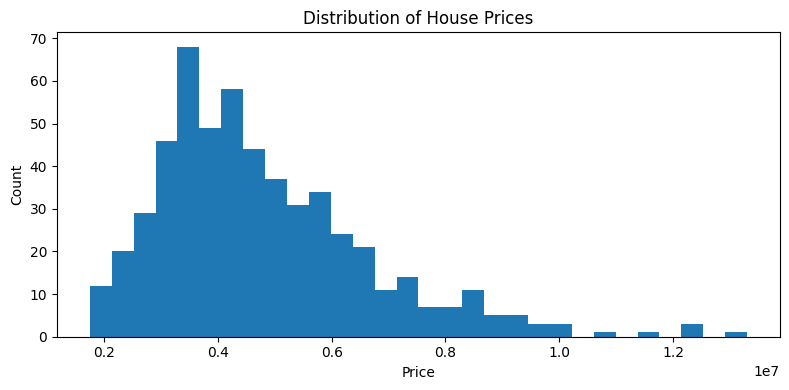

Generating Correlation Heatmap...


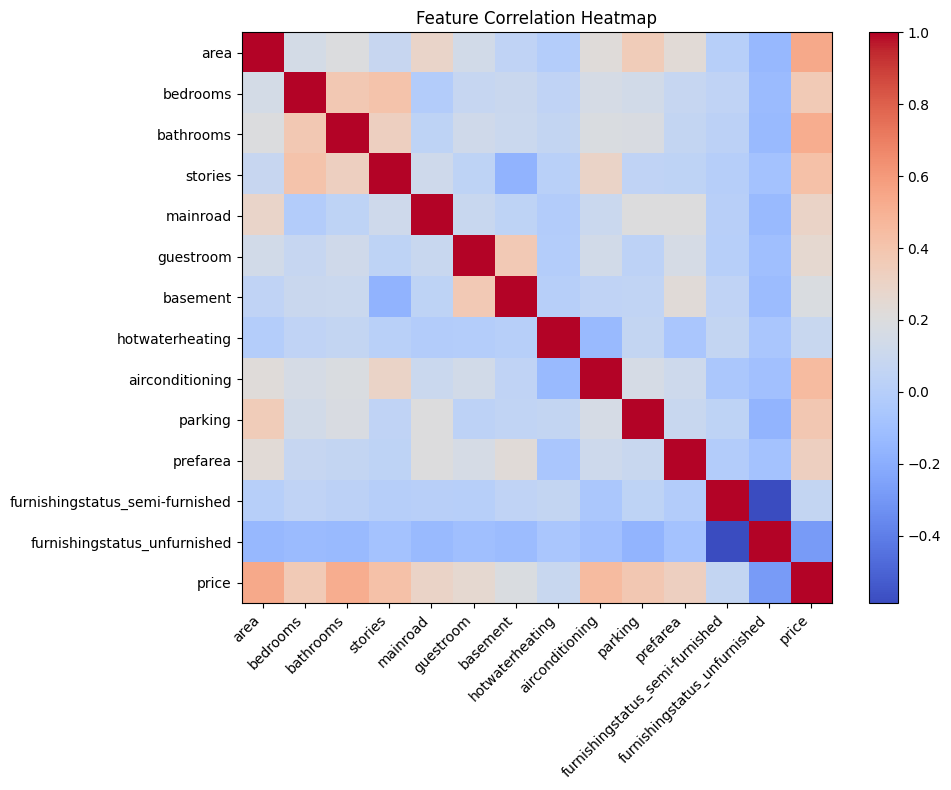

Generating Actual vs Predicted Scatter Plot...


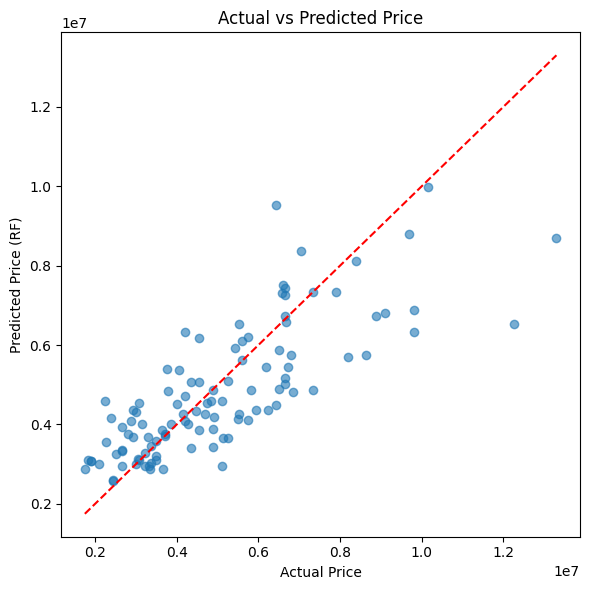

Generating Price vs Area Scatter Plot...


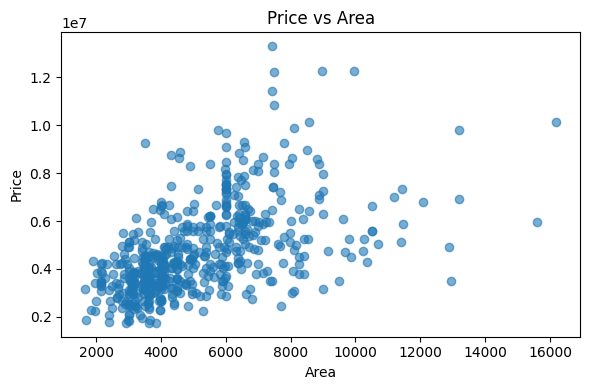


ALL TASKS COMPLETED SUCCESSFULLY!


In [5]:

# ============================================
# TASK 4: VISUALIZATION
# ============================================
print("\n" + "="*50)
print("TASK 4: VISUALIZATION")
print("="*50)

# Histogram of prices
print("\nGenerating Price Distribution Histogram...")
plt.figure(figsize=(8,4))
if sns:
    sns.histplot(df['price'].dropna(), bins=30, kde=True)
else:
    plt.hist(df['price'].dropna(), bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap for features vs price
print("Generating Correlation Heatmap...")
corr_cols = [c for c in features + [target] if c in df.columns]
cm = df[corr_cols].corr()
plt.figure(figsize=(10,8))
if sns:
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', square=True)
else:
    im = plt.imshow(cm, cmap='coolwarm', aspect='auto')
    plt.colorbar(im)
    plt.xticks(range(len(cm.columns)), cm.columns, rotation=45, ha='right')
    plt.yticks(range(len(cm.index)), cm.index)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Actual vs Predicted (Random Forest)
print("Generating Actual vs Predicted Scatter Plot...")
pred_df = df.loc[df.get('pred_rf').notnull(), ['price','pred_rf']] if 'pred_rf' in df.columns else pd.DataFrame()
if not pred_df.empty:
    plt.figure(figsize=(6,6))
    plt.scatter(pred_df['price'], pred_df['pred_rf'], alpha=0.6)
    minv, maxv = pred_df['price'].min(), pred_df['price'].max()
    plt.plot([minv, maxv], [minv, maxv], 'r--')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price (RF)')
    plt.title('Actual vs Predicted Price')
    plt.tight_layout()
    plt.show()

# Price vs Area scatter
print("Generating Price vs Area Scatter Plot...")
if 'area' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(6,4))
    if sns:
        sns.scatterplot(x=df['area'], y=df['price'], alpha=0.6)
    else:
        plt.scatter(df['area'], df['price'], alpha=0.6)
    plt.xlabel('Area')
    plt.ylabel('Price')
    plt.title('Price vs Area')
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*50)


## Task 5 — Insights & Summary
- Area (property size) is the strongest driver of price, followed by number of bedrooms and bathrooms. Preferred area (`prefarea`) and parking also show positive relationships. Furnishing status has a moderate effect.
- Model accuracy:
  - Linear Regression — MAE: 970,043.40, RMSE: 1,324,506.96, R2: 0.6529.
  - Random Forest — MAE: 1,022,560.05, RMSE: 1,401,496.84, R2: 0.6114.
so Linear Regression performed slightly better on MAE here.
- The model captures broad trends but errors are large relative to absolute prices, so predictions should be used as guidance rather than exact quotes.
- A surprise: furnishing status had less impact than expected compared with area and basic amenities.
- Recommendation: for a real-estate business, prioritize marketing larger and well-located properties, and highlight quantifiable attributes (area, bedrooms, bathrooms, prefarea) to justify pricing; collect more granular features (age, renovations) to improve future models.
